In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [10]:
from sklearn.datasets import make_regression
x, y = make_regression(n_samples=1000, n_features=2, n_targets=1, noise=3, random_state=1)

In [11]:
x

array([[-0.91542437, -1.94504696],
       [-2.30490794, -0.59246129],
       [-0.43750898, -0.78191168],
       ...,
       [-0.46867382,  0.02186284],
       [-0.44265541,  0.55753264],
       [-0.13971173,  0.85328219]], shape=(1000, 2))

In [4]:
y

array([ 6.49648659e+01,  5.94888213e+01,  8.00860626e+01, -1.08431085e+02,
       -3.54393286e+01, -3.20308653e+02,  1.64344735e+02, -4.48180379e+01,
        9.99149230e+01,  5.64957757e+01, -8.43902997e+01,  5.45880291e+01,
       -1.60276063e+02,  1.81014418e+00,  1.23576887e+02,  2.60463045e+01,
       -2.16363958e+02,  2.51396500e+01,  1.43544748e+02, -1.81915289e+02,
        1.76743951e+02,  4.42287609e+01,  8.63143921e+01,  3.48909319e+01,
        2.85728955e+01,  2.72615468e+01, -1.23826074e+01,  1.26114865e+02,
        6.06778650e+00, -1.86520488e+01,  1.12137618e+01, -2.82041201e+01,
        3.48993267e+01,  5.89207626e+01,  1.15869193e+02, -1.50679938e+01,
       -5.68571803e+00,  3.29320500e+01, -7.75889481e+00, -1.33465340e+01,
       -1.03414825e+02, -7.41861407e+01, -6.32213125e+01,  5.92514101e+01,
       -1.71361766e+01,  9.34063615e+01,  4.60921977e+01,  3.81317385e+01,
       -1.22401298e+02,  4.86535297e+01, -7.01926781e+01,  9.03400064e+01,
       -1.68597908e+02,  

<Axes: xlabel='0', ylabel='1'>

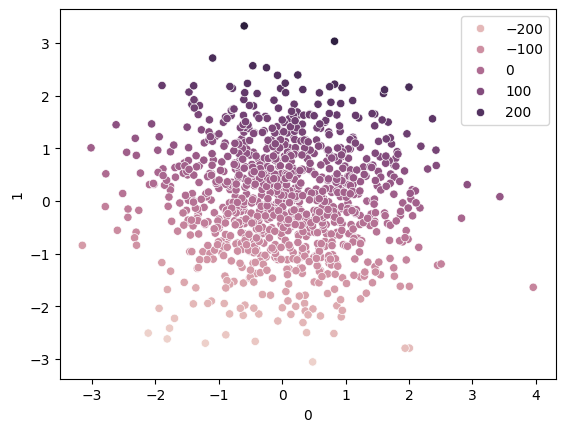

In [12]:
sns.scatterplot(x = pd.DataFrame(x)[0], y = pd.DataFrame(x)[1], hue=y)

In [13]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=1)

In [22]:
from sklearn.svm import SVR
svr = SVR(kernel='linear')

In [23]:
svr.fit(x_train,y_train)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [24]:
svr.coef_

array([[16.54489974, 87.43418522]])

In [25]:
y_pred = svr.predict(x_test)

In [26]:
y_pred

array([-3.52385869e+01, -9.36124188e+01,  1.65223996e+02,  2.13963645e+01,
        7.53408311e+01,  2.32244331e+01, -1.71589710e+01,  1.49004458e+02,
       -1.64026245e+02,  1.06037602e+02,  5.99630787e+01,  2.09178806e+01,
       -7.11188407e+01,  1.04042528e+02,  2.09327942e+01, -1.59354006e+02,
        1.57109294e+02,  3.71335992e+01, -2.12324784e+01, -1.28437043e+01,
       -1.70876615e+02,  1.19511016e+01,  2.11338465e+01,  4.27907278e+01,
        3.20277002e+01,  1.95074775e+01, -7.38659108e+01, -8.18533528e+01,
        1.45632329e+02,  2.78843509e+02,  2.17148778e+02,  2.81971416e+01,
        1.01294404e+02,  3.44881914e+01,  6.55921637e+01,  2.97621363e+01,
       -7.75988217e+01,  1.04603545e+02, -1.84961503e+02, -1.94624597e+01,
        1.53102784e+02,  1.39629460e+02, -3.96562033e+01, -2.00859576e+02,
       -3.70736439e+01,  1.01326150e+01, -4.55109013e+01,  8.89033422e+01,
       -5.62198506e+01, -4.43572432e+01,  4.82820800e+01,  3.69513175e+01,
        9.00499872e+00, -

In [28]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9988796642647081

In [29]:
#Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
params = {'C': [0.1,0.2,1,2,3,10,50,100],
          'gamma': [1,0.1,0.2,0.001,0.003],
          'kernel': ['linear'],
          'epsilon': [0.01,0.1,0.2, 0.3]}

In [30]:
model = GridSearchCV(SVR(), param_grid=params, cv=5, verbose=3)

In [31]:
model.fit(x_train,y_train)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
[CV 1/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.747 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.738 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.743 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.754 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.749 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.747 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.738 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.743 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.754 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.749 total time=   0.0s
[CV 1/5] END C=0.1, epsilon

,estimator,SVR()
,param_grid,"{'C': [0.1, 0.2, ...], 'epsilon': [0.01, 0.1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['linear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'linear'


In [32]:
model.best_params_

{'C': 100, 'epsilon': 0.2, 'gamma': 1, 'kernel': 'linear'}

In [33]:
model.best_score_

np.float64(0.9989202936549859)

In [34]:
y_pred = model.best_estimator_.predict(x_test)

In [35]:
y_pred

array([-3.55324656e+01, -9.41804992e+01,  1.66038722e+02,  2.14002892e+01,
        7.56745006e+01,  2.32597114e+01, -1.73159636e+01,  1.49697836e+02,
       -1.64965099e+02,  1.06544818e+02,  6.02349039e+01,  2.09496077e+01,
       -7.15646437e+01,  1.04505683e+02,  2.09877316e+01, -1.60285142e+02,
        1.57858957e+02,  3.72673466e+01, -2.14172685e+01, -1.29737261e+01,
       -1.71860586e+02,  1.19719658e+01,  2.11690184e+01,  4.29851116e+01,
        3.20853412e+01,  1.95427532e+01, -7.43051909e+01, -8.23723677e+01,
        1.46336283e+02,  2.80240527e+02,  2.18241906e+02,  2.82796991e+01,
        1.01767311e+02,  3.46356204e+01,  6.58461834e+01,  2.98560372e+01,
       -7.80574280e+01,  1.05086871e+02, -1.85999624e+02, -1.96266251e+01,
        1.53851588e+02,  1.40285329e+02, -3.99209657e+01, -2.01973674e+02,
       -3.73125023e+01,  1.01200844e+01, -4.57836442e+01,  8.92707704e+01,
       -5.66054975e+01, -4.46479084e+01,  4.84896175e+01,  3.70368948e+01,
        8.98245276e+00, -

In [37]:
r2_score(y_test,y_pred)

0.9989064821190069